<a href="https://colab.research.google.com/github/diipperss/DNN_GroupProject/blob/main/PartF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Part F:Flowers Recognition



---




In [21]:
!pip install torch torchvision matplotlib scikit-learn

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torchvision.datasets import Flowers102
from torch.utils.data import DataLoader, Subset
from torchvision.models import resnet18

import numpy as np
import random
from tqdm import tqdm

In [24]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

train_dataset = Flowers102(root="./data", split="train", download=True, transform=transform)
val_dataset   = Flowers102(root="./data", split="val", download=True, transform=transform)
test_dataset  = Flowers102(root="./data", split="test", download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [27]:
class FlowerNet(nn.Module):
    def __init__(self, num_classes=102):
        super().__init__()

        self.model = resnet18(pretrained=True)

        in_features = self.model.fc.in_features

        self.model.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.model(x)

model = FlowerNet().to(device)

In [28]:
def mixup_data(x, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size(0)

    index = torch.randperm(batch_size).to(device)

    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]

    return mixed_x, y_a, y_b, lam

In [29]:
criterion = nn.CrossEntropyLoss()

def mixup_loss(pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [30]:
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [31]:
def train_one_epoch():
    model.train()
    total_loss = 0

    for x, y in tqdm(train_loader):
        x, y = x.to(device), y.to(device)

        # MixUp
        x, y_a, y_b, lam = mixup_data(x, y)

        outputs = model(x)
        loss = mixup_loss(outputs, y_a, y_b, lam)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

In [32]:
def evaluate():
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            outputs = model(x)
            _, preds = torch.max(outputs, 1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

In [33]:
def few_shot(dataset, shots=5):
    class_to_indices = {i: [] for i in range(102)}

    for idx, (_, label) in enumerate(dataset):
        class_to_indices[label].append(idx)

    selected = []
    for c in class_to_indices:
        selected.extend(random.sample(class_to_indices[c], shots))

    return Subset(dataset, selected)

few_shot_train = few_shot(train_dataset, shots=5)
few_shot_loader = DataLoader(few_shot_train, batch_size=32, shuffle=True)

In [34]:
epochs = 5

for epoch in range(epochs):
    loss = train_one_epoch()
    acc = evaluate()

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Loss: {loss:.4f}")
    print(f"Val Accuracy: {acc:.4f}")
    print("-" * 30)

100%|██████████| 32/32 [00:10<00:00,  3.07it/s]


Epoch 1/5
Loss: 4.5317
Val Accuracy: 0.2127
------------------------------


100%|██████████| 32/32 [00:08<00:00,  3.66it/s]


Epoch 2/5
Loss: 4.0261
Val Accuracy: 0.4392
------------------------------


100%|██████████| 32/32 [00:08<00:00,  3.84it/s]


Epoch 3/5
Loss: 3.4547
Val Accuracy: 0.5833
------------------------------


100%|██████████| 32/32 [00:08<00:00,  3.72it/s]


Epoch 4/5
Loss: 2.8543
Val Accuracy: 0.6853
------------------------------


100%|██████████| 32/32 [00:08<00:00,  3.66it/s]


Epoch 5/5
Loss: 2.1899
Val Accuracy: 0.7941
------------------------------


In [35]:
def test_accuracy():
    model.eval()
    correct = 0
    total = 0

    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)

            outputs = model(x)
            _, preds = torch.max(outputs, 1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    print("Test Accuracy:", correct / total)

test_accuracy()

Test Accuracy: 0.7436981623028135


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

In [37]:
model.eval()

all_preds = []
all_labels = []

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        outputs = model(x)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.numpy())

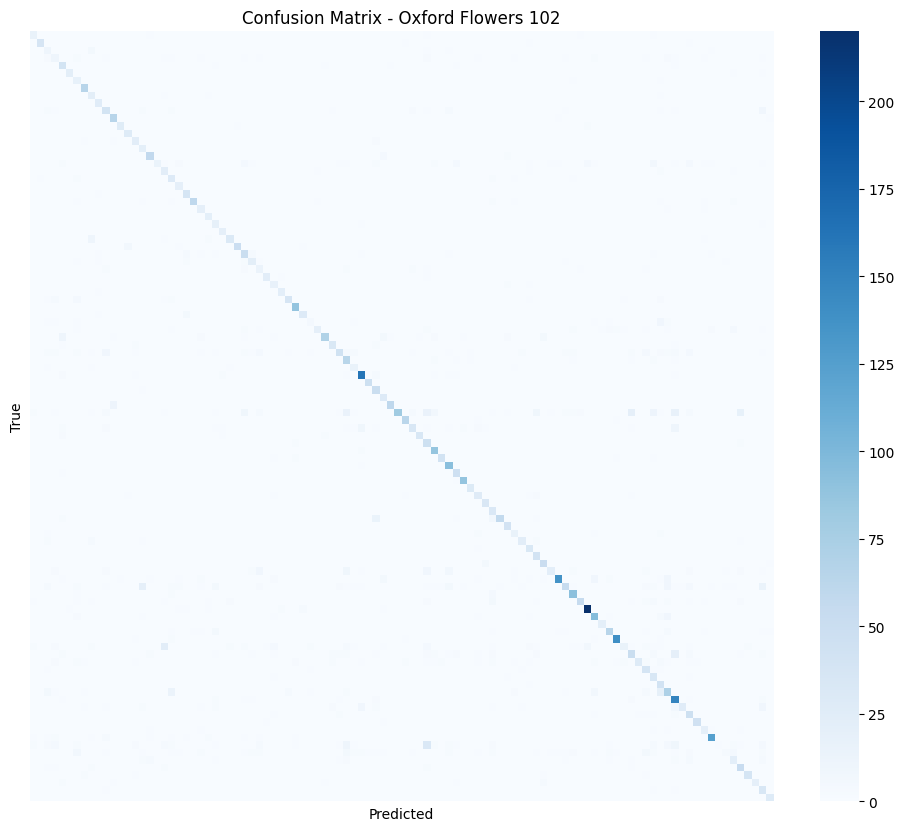

In [38]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap="Blues", xticklabels=False, yticklabels=False)
plt.title("Confusion Matrix - Oxford Flowers 102")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [39]:
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.67      0.80      0.73        20
           1       0.97      0.93      0.95        40
           2       0.28      0.55      0.37        20
           3       0.27      0.28      0.27        36
           4       0.57      0.89      0.70        45
           5       0.96      0.92      0.94        25
           6       0.35      0.90      0.51        20
           7       0.92      1.00      0.96        65
           8       0.43      0.88      0.58        26
           9       0.83      1.00      0.91        25
          10       0.58      0.60      0.59        67
          11       0.81      0.97      0.88        67
          12       0.96      0.90      0.93        29
          13       0.78      1.00      0.88        28
          14       0.71      0.83      0.76        29
          15       0.40      1.00      0.58        21
          16       0.85      0.89      0.87        65
          17       1.00    